# Personal Expense Analysis

## Project Objective

This project analyzes personal expense transactions from March 2023
to understand spending patterns, frequently purchased items,
high-value expenses, category-based spending, and time-based
spending behavior.

### Key Questions

1. How much was spent during the month?
2. What items were purchased most frequently?
3. Which items accounted for the most spending?
4. How does spending differ by category?
5. Which days and times had the highest spending?
6. Are there unusually high-value transactions?

In [101]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

print(pd.__version__)
expenses = pd.read_csv("D:/Projects/Personal Expense Intelligence/data/raw/myExpenses1.csv")

2.3.3


In [102]:
expenses.shape
expenses.head()

,Date,Item,Amount,Category,Time,day
0,01-03-2023,chai,7,alone,07:00,Wednesday
1,01-03-2023,chai,20,friend,10:00,Wednesday
2,01-03-2023,juice,15,friend,13:00,Wednesday
3,01-03-2023,rikshow,12,alone,14:00,Wednesday
4,01-03-2023,coffee,12,alone,15:00,Wednesday


In [103]:
expenses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      145 non-null    object
 1   Item      145 non-null    object
 2   Amount    145 non-null    int64 
 3   Category  144 non-null    object
 4   Time      145 non-null    object
 5   day       145 non-null    object
dtypes: int64(1), object(5)
memory usage: 6.9+ KB


In [104]:
expenses[expenses["Category"].isna()]
expenses.loc[68:76]

,Date,Item,Amount,Category,Time,day
68,12-03-2023,coldrink,20,friend,14:10,Sunday
69,12-03-2023,chai,10,friend,18:00,Sunday
70,12-03-2023,recharge,210,alone,12:00,Sunday
71,12-03-2023,coldrink,10,friend,21:00,Sunday
72,12-03-2023,others,10,NaN,18:30,Sunday
73,13-03-2023,chai,10,alone,07:00,Monday
74,13-03-2023,petrol,70,friend,10:00,Monday
75,13-03-2023,juice,25,friend,11:00,Monday
76,13-03-2023,coffee,12,alone,17:00,Monday


In [105]:
expenses["Category"].value_counts(dropna=False)

Category
alone     91
friend    53
NaN        1
Name: count, dtype: int64

In [106]:
expenses["Amount"].describe()

count    145.000000
mean      31.786207
std       56.389541
min        5.000000
25%       12.000000
50%       17.000000
75%       30.000000
max      500.000000
Name: Amount, dtype: float64

In [107]:
expenses.loc[expenses["Amount"].idxmax()]

Date        05-03-2023
Item              shoe
Amount             500
Category         alone
Time             17:30
day             Sunday
Name: 32, dtype: object

In [108]:
expenses["Item"].value_counts()

Item
chai with snaks    48
chai               21
others             16
coldrink           11
coffee             10
juice               9
rikshow             4
biryani             4
idli                3
chicken             3
samosa              3
ice cream           2
shoe                1
chiness bhel        1
choclate            1
pizza               1
chass               1
faluda              1
wifi                1
recharge            1
petrol              1
freanky             1
maggi               1
Name: count, dtype: int64

In [109]:
expenses["Date"].head(10)

0    01-03-2023
1    01-03-2023
2    01-03-2023
3    01-03-2023
4    01-03-2023
5    01-03-2023
6    01-03-2023
7    01-03-2023
8    02-03-2023
9    02-03-2023
Name: Date, dtype: object

In [110]:
expenses["Date"].nunique()
expenses[["Date", "day"]].head(10)

,Date,day
0,01-03-2023,Wednesday
1,01-03-2023,Wednesday
2,01-03-2023,Wednesday
3,01-03-2023,Wednesday
4,01-03-2023,Wednesday
5,01-03-2023,Wednesday
6,01-03-2023,Wednesday
7,01-03-2023,Wednesday
8,02-03-2023,Thursday
9,02-03-2023,Thursday


In [111]:
expenses.dtypes

Date        object
Item        object
Amount       int64
Category    object
Time        object
day         object
dtype: object

In [112]:
expenses["Date"].min()
expenses["Date"].max()
expenses["Amount"].sum()

np.int64(4609)

In [113]:
expenses.groupby("Item")["Amount"].sum().sort_values(ascending=False).head(5)

Item
chai with snaks    1080
biryani             580
shoe                500
wifi                350
others              335
Name: Amount, dtype: int64

In [114]:
top5 = expenses.groupby("Item")["Amount"].sum().sort_values(ascending=False).head(5)
top5.sum()

np.int64(2845)

In [115]:
average_expense = expenses["Amount"].mean()

print("Average expense:", average_expense)

Average expense: 31.786206896551725


In [116]:
spending_by_item = (
    expenses
    .groupby("Item")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(spending_by_item)

Item
chai with snaks    1080
biryani             580
shoe                500
wifi                350
others              335
juice               210
recharge            210
chai                200
chicken             180
coldrink            165
coffee              120
idli                105
pizza               100
freanky              70
petrol               70
ice cream            65
chiness bhel         60
faluda               50
samosa               49
rikshow              48
maggi                30
chass                17
choclate             15
Name: Amount, dtype: int64

In [117]:
top5 = expenses.groupby("Item")["Amount"].sum().sort_values(ascending=False).head(5)

top5.sum() / expenses["Amount"].sum() * 100

np.float64(61.72705576046865)

In [118]:
spending_by_category = (
    expenses
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(spending_by_category)

Category
alone     2710
friend    1889
Name: Amount, dtype: int64

In [119]:
category_analysis = (
    expenses
    .groupby("Category")
    .agg(
        Transactions=("Amount", "count"),
        Total_Spent=("Amount", "sum"),
        Average_Spent=("Amount", "mean")
    )
    .sort_values("Total_Spent", ascending=False)
)

display(category_analysis)

,Transactions,Total_Spent,Average_Spent
Category,,,
alone,91,2710,29.780220
friend,53,1889,35.641509


In [120]:
category_analysis["Total_Spent"].idxmax()
category_analysis["Total_Spent"].max()

np.int64(2710)

In [121]:
category_percentage = (
    spending_by_category / expenses["Amount"].sum()
) * 100

display(category_percentage)

Category
alone     58.798004
friend    40.985029
Name: Amount, dtype: float64

In [122]:
# ============================================================
# 7. BASIC SPENDING METRICS
# ============================================================

total_spending = expenses["Amount"].sum()
average_expense = expenses["Amount"].mean()
median_expense = expenses["Amount"].median()
minimum_expense = expenses["Amount"].min()
maximum_expense = expenses["Amount"].max()

print(f"Total spending: ₹{total_spending:,.2f}")
print(f"Average expense: ₹{average_expense:,.2f}")
print(f"Median expense: ₹{median_expense:,.2f}")
print(f"Minimum expense: ₹{minimum_expense:,.2f}")
print(f"Maximum expense: ₹{maximum_expense:,.2f}")

Total spending: ₹4,609.00
Average expense: ₹31.79
Median expense: ₹17.00
Minimum expense: ₹5.00
Maximum expense: ₹500.00


In [123]:
# ============================================================
# 8. DATE ANALYSIS
# ============================================================

print("Date data type:", expenses["Date"].dtype)

print("Earliest date:", expenses["Date"].min())
print("Latest date:", expenses["Date"].max())

print("Number of unique dates:", expenses["Date"].nunique())

Date data type: object
Earliest date: 01-03-2023
Latest date: 31-03-2023
Number of unique dates: 31


In [124]:
# ============================================================
# 10. ITEM FREQUENCY
# ============================================================

item_frequency = expenses["Item"].value_counts()

display(item_frequency)

Item
chai with snaks    48
chai               21
others             16
coldrink           11
coffee             10
juice               9
rikshow             4
biryani             4
idli                3
chicken             3
samosa              3
ice cream           2
shoe                1
chiness bhel        1
choclate            1
pizza               1
chass               1
faluda              1
wifi                1
recharge            1
petrol              1
freanky             1
maggi               1
Name: count, dtype: int64

In [125]:
# ============================================================
# 16. SPENDING BY CATEGORY
# ============================================================

spending_by_category = (
    expenses
    .groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

display(spending_by_category)

Category
alone     2710
friend    1889
Name: Amount, dtype: int64

In [126]:
# ============================================================
# 17. COMPLETE CATEGORY ANALYSIS
# ============================================================

category_analysis = (
    expenses
    .groupby("Category")
    .agg(
        Transactions=("Amount", "count"),
        Total_Spent=("Amount", "sum"),
        Average_Spent=("Amount", "mean")
    )
    .sort_values("Total_Spent", ascending=False)
)

display(category_analysis)

,Transactions,Total_Spent,Average_Spent
Category,,,
alone,91,2710,29.780220
friend,53,1889,35.641509


In [127]:
# ============================================================
# 18. CATEGORY SPENDING PERCENTAGE
# ============================================================

category_percentage = (
    spending_by_category / total_spending
) * 100

display(category_percentage)

Category
alone     58.798004
friend    40.985029
Name: Amount, dtype: float64

In [128]:
# ============================================================
# 19. COMPLETE ITEM ANALYSIS
# ============================================================

item_analysis = (
    expenses
    .groupby("Item")
    .agg(
        Transactions=("Amount", "count"),
        Total_Spent=("Amount", "sum"),
        Average_Spent=("Amount", "mean")
    )
    .sort_values("Total_Spent", ascending=False)
)

display(item_analysis)

,Transactions,Total_Spent,Average_Spent
Item,,,
chai with snaks,48,1080,22.500000
biryani,4,580,145.000000
shoe,1,500,500.000000
wifi,1,350,350.000000
others,16,335,20.937500
juice,9,210,23.333333
recharge,1,210,210.000000
chai,21,200,9.523810
chicken,3,180,60.000000


In [129]:
# ============================================================
# 20. TOP 10 INDIVIDUAL TRANSACTIONS
# ============================================================

top_transactions = (
    expenses
    .sort_values("Amount", ascending=False)
    .head(10)
)

display(top_transactions)

,Date,Item,Amount,Category,Time,day
32,05-03-2023,shoe,500,alone,17:30,Sunday
49,08-03-2023,wifi,350,alone,10:30,Wednesday
70,12-03-2023,recharge,210,alone,12:00,Sunday
46,07-03-2023,biryani,200,friend,23:30,Tuesday
129,27-03-2023,biryani,180,friend,16:00,Monday
67,12-03-2023,biryani,100,friend,14:00,Sunday
87,16-03-2023,biryani,100,friend,13:00,Thursday
44,07-03-2023,pizza,100,friend,21:00,Tuesday
97,19-03-2023,chicken,70,friend,21:00,Sunday
127,27-03-2023,juice,70,friend,15:00,Monday


In [130]:
# ============================================================
# 21. LARGEST TRANSACTION
# ============================================================

largest_transaction = expenses.loc[
    expenses["Amount"].idxmax()
]

display(largest_transaction)

Date        05-03-2023
Item              shoe
Amount             500
Category         alone
Time             17:30
day             Sunday
Name: 32, dtype: object

In [131]:
# ============================================================
# 22. CONVERT TIME TO DATETIME
# ============================================================

# Convert time strings to datetime, coercing invalid values to NaT
expenses["Time"] = pd.to_datetime(
    expenses["Time"],
    format="%H:%M",
    errors="coerce"
).dt.time

print(expenses["Time"].dtype)

object


In [132]:
# ============================================================
# 23. EXTRACT HOUR
# ============================================================

expenses["Hour"] = expenses["Time"].dt.hour

display(
    expenses[["Time", "Hour"]].head(10)
)

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
# ============================================================
# 24. SPENDING BY HOUR
# ============================================================

spending_by_hour = (
    expenses
    .groupby("Hour")["Amount"]
    .sum()
    .sort_index()
)

display(spending_by_hour)

Series([], Name: Amount, dtype: int64)

In [ ]:
# ============================================================
# 25. TRANSACTIONS BY HOUR
# ============================================================

transactions_by_hour = (
    expenses["Hour"]
    .value_counts()
    .sort_index()
)

display(transactions_by_hour)

Series([], Name: count, dtype: int64)

In [ ]:
# ============================================================
# 26. CREATE TIME PERIOD
# ============================================================

def get_time_period(hour):

    if hour < 12:
        return "Morning"

    elif hour < 17:
        return "Afternoon"

    elif hour < 21:
        return "Evening"

    else:
        return "Night"


expenses["Time_Period"] = expenses["Hour"].apply(
    get_time_period
)

display(
    expenses[["Time", "Hour", "Time_Period"]].head(10)
)

,Time,Hour,Time_Period
0,NaT,NaN,Night
1,NaT,NaN,Night
2,NaT,NaN,Night
3,NaT,NaN,Night
4,NaT,NaN,Night
5,NaT,NaN,Night
6,NaT,NaN,Night
7,NaT,NaN,Night
8,NaT,NaN,Night
9,NaT,NaN,Night


In [ ]:
# ============================================================
# 28. TRANSACTIONS BY TIME PERIOD
# ============================================================

transactions_by_period = (
    expenses["Time_Period"]
    .value_counts()
)

display(transactions_by_period)

Time_Period
Night    145
Name: count, dtype: int64

In [ ]:
# ============================================================
# 29. SPENDING BY DAY OF WEEK
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

spending_by_day = (
    expenses
    .groupby("day")["Amount"]
    .sum()
    .reindex(day_order)
)

display(spending_by_day)


day
Monday        670
Tuesday       691
Wednesday     720
Thursday      493
Friday        356
Saturday      402
Sunday       1277
Name: Amount, dtype: int64

In [ ]:
# ============================================================
# 30. TRANSACTIONS BY DAY OF WEEK
# ============================================================

transactions_by_day = (
    expenses["day"]
    .value_counts()
    .reindex(day_order)
)

display(transactions_by_day)

day
Monday       21
Tuesday      19
Wednesday    23
Thursday     22
Friday       20
Saturday     20
Sunday       20
Name: count, dtype: int64

In [ ]:
# ============================================================
# 31. DAILY SPENDING
# ============================================================

daily_spending = (
    expenses
    .groupby("Date")["Amount"]
    .sum()
    .sort_index()
)

display(daily_spending)

Date
01-03-2023    111
02-03-2023    131
03-03-2023    117
04-03-2023    126
05-03-2023    632
06-03-2023     71
07-03-2023    432
08-03-2023    422
09-03-2023     60
10-03-2023     47
11-03-2023    154
12-03-2023    390
13-03-2023    147
14-03-2023     94
15-03-2023     52
16-03-2023    135
17-03-2023     52
18-03-2023     55
19-03-2023    130
20-03-2023    125
21-03-2023     60
22-03-2023    130
23-03-2023     50
24-03-2023     80
25-03-2023     67
26-03-2023    125
27-03-2023    327
28-03-2023    105
29-03-2023     50
30-03-2023     72
31-03-2023     60
Name: Amount, dtype: int64

In [ ]:
# ============================================================
# 32. HIGHEST-SPENDING DAY
# ============================================================

highest_spending_day = daily_spending.idxmax()
highest_spending_amount = daily_spending.max()

print("Highest spending day:", highest_spending_day)
print(f"Amount spent: ₹{highest_spending_amount:,.2f}")

Highest spending day: 05-03-2023
Amount spent: ₹632.00


In [ ]:
# ============================================================
# 33. LOWEST-SPENDING DAY
# ============================================================

lowest_spending_day = daily_spending.idxmin()
lowest_spending_amount = daily_spending.min()

print("Lowest spending day:", lowest_spending_day)
print(f"Amount spent: ₹{lowest_spending_amount:,.2f}")

Lowest spending day: 10-03-2023
Amount spent: ₹47.00


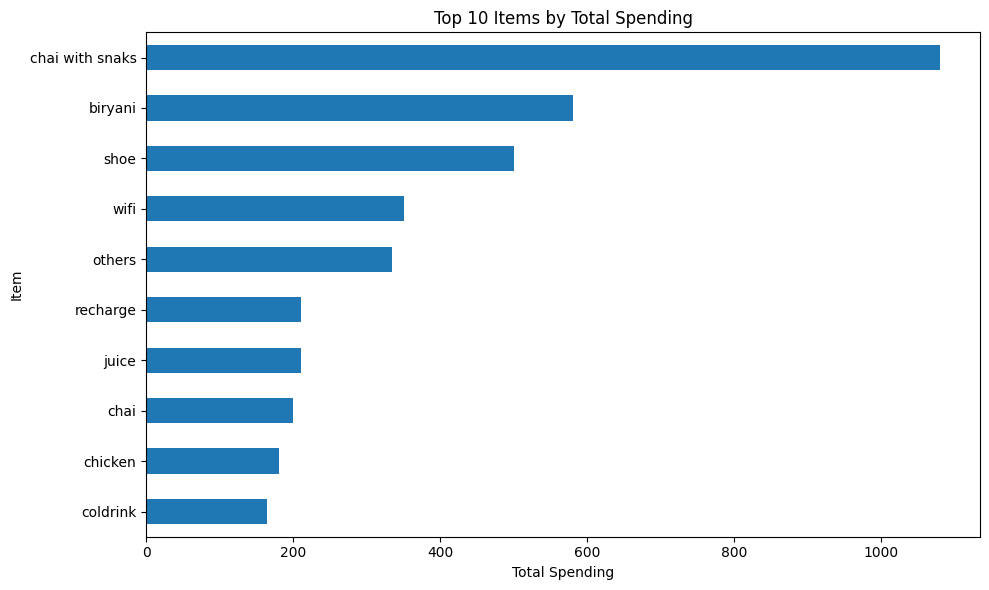

In [ ]:
top_items = spending_by_item.head(10)

plt.figure(figsize=(10, 6))

top_items.sort_values().plot(kind="barh")

plt.title("Top 10 Items by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Item")

plt.tight_layout()
plt.show()

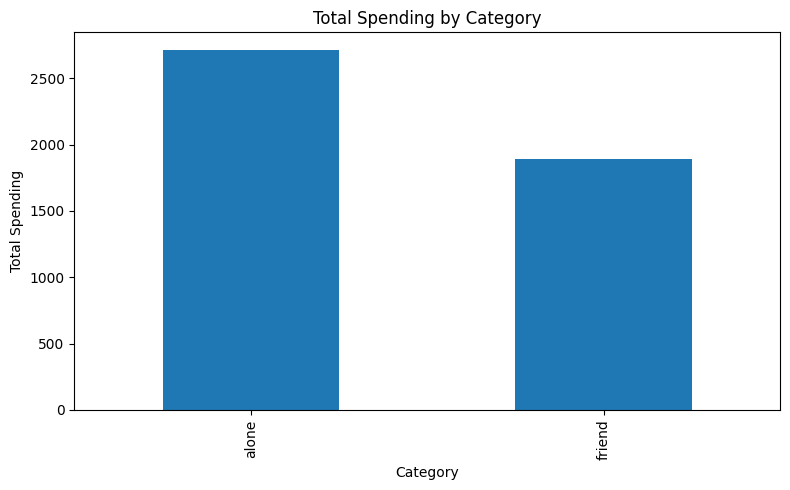

In [ ]:
plt.figure(figsize=(8, 5))

spending_by_category.plot(kind="bar")

plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

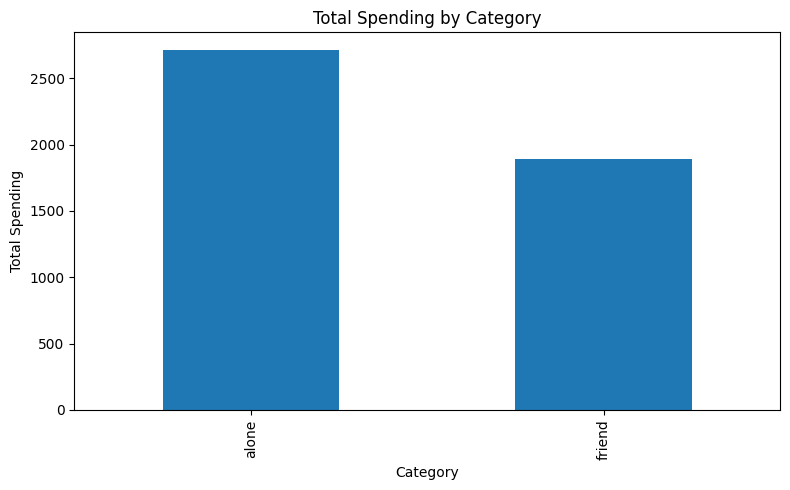

In [ ]:
plt.figure(figsize=(8, 5))

spending_by_category.plot(kind="bar")

plt.title("Total Spending by Category")
plt.xlabel("Category")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

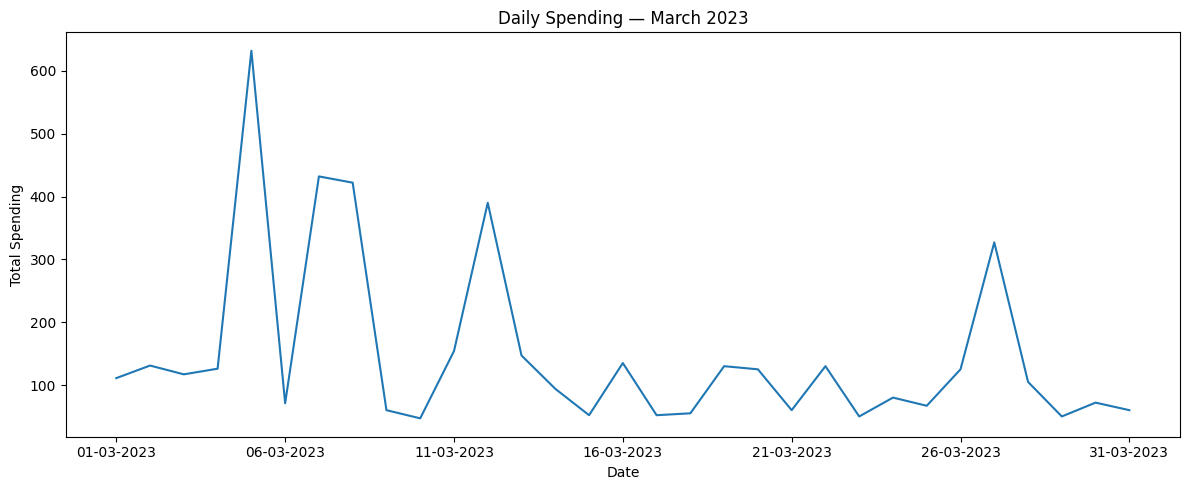

In [ ]:
plt.figure(figsize=(12, 5))

daily_spending.plot()

plt.title("Daily Spending — March 2023")
plt.xlabel("Date")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

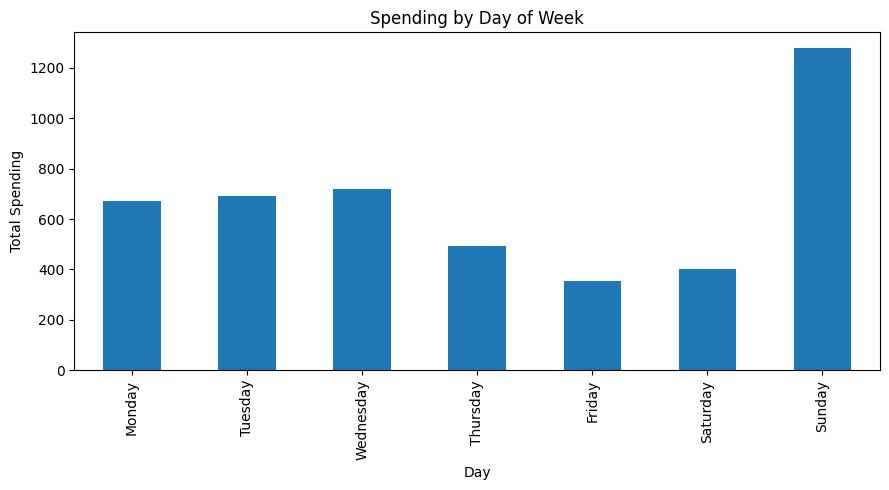

In [ ]:
plt.figure(figsize=(9, 5))

spending_by_day.plot(kind="bar")

plt.title("Spending by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

In [ ]:
expenses.to_csv(
    "../data/processed/expenses_cleaned.csv",
    index=False
)

In [ ]:
print("PERSONAL EXPENSE INTELLIGENCE")
print("=" * 40)

print(f"Total transactions: {len(expenses)}")
print(f"Total spending: ₹{expenses['Amount'].sum():,.2f}")
print(f"Average transaction: ₹{expenses['Amount'].mean():,.2f}")
print(f"Median transaction: ₹{expenses['Amount'].median():,.2f}")
print(f"Largest transaction: ₹{expenses['Amount'].max():,.2f}")
print(f"Smallest transaction: ₹{expenses['Amount'].min():,.2f}")
print(f"Unique items: {expenses['Item'].nunique()}")
print(f"Unique dates: {expenses['Date'].nunique()}")

PERSONAL EXPENSE INTELLIGENCE
Total transactions: 145
Total spending: ₹4,609.00
Average transaction: ₹31.79
Median transaction: ₹17.00
Largest transaction: ₹500.00
Smallest transaction: ₹5.00
Unique items: 23
Unique dates: 31


### Key Insights

- The dataset contains **145 expense transactions** recorded across **31 days** in March 2023.
- Total recorded spending was **₹4,609**.
- The average transaction value was approximately **₹31.79**, while the median was **₹17**, indicating that higher-value transactions are pulling the average upward.
- The most frequently recorded expense was **chai with snacks**, with **48 transactions**.
- Chai with snacks also had the highest total spending at **₹1,080**.
- The five highest-spending items were **chai with snacks, biryani, shoe, wifi, and others**, together accounting for approximately **61.7% of total spending**.
- The largest individual transaction was **₹500 for shoes**. This was treated as a potentially unusual observation rather than automatically being classified as an error.
- The `Category` column contains **91 transactions marked as alone, 53 as friend, and 1 missing value**.
- Several item names contain spelling inconsistencies, highlighting the need for data standardization during the cleaning stage.


## Conclusion

The analysis provides an overview of spending behavior during March
2023. The results show that a relatively small number of expense
items account for a large proportion of total spending, while the
difference between the mean and median highlights the influence of
higher-value transactions.

The analysis also identified data-quality issues such as a missing
category value and inconsistent item names. These issues should be
addressed carefully before using the dataset for more advanced
analysis or predictive modeling.

Further analysis of spending by category, day, and time can provide
additional insights into spending behavior.